In [5]:
from langchain_groq import ChatGroq
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages
from IPython.display import Image, display 

c:\Users\Raviteja\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
groq_api_key = 'your_api_key'
llm = ChatGroq(groq_api_key=groq_api_key, model_name="llama-3.3-70b-versatile")

In [8]:
class State(TypedDict):
    messages:Annotated[list, add_messages] 
    sentiment: str 
    
def preprocess(state: State) -> State:
    cleaned = state['messages'][-1].content.strip() 
    state['messages'][-1].content = cleaned 
    return state 

def analyze_sentiment(state: State) -> State:
    msg = state["messages"][-1].content
    state["sentiment"] = 'positive' if 'good' in msg else 'neutral'
    return state

def chatbot(state: State) -> State:
    return {'messages': llm.invoke(state['messages'])}

def logger(state: State) -> State:
    print(f"LOG: {state['messages'][-1].content}, Sentiment: {state.get('sentiment')}")
    return state    
    
    

In [9]:
builder = StateGraph(State)
builder.add_node('preprocess', preprocess)
builder.add_node('analyze_sentiment', analyze_sentiment)
builder.add_node('chatbot',chatbot)
builder.add_node('logger', logger)

In [10]:
builder.add_edge(START,'preprocess')
builder.add_edge('preprocess','analyze_sentiment')
builder.add_edge('analyze_sentiment', 'chatbot')
builder.add_edge('chatbot', 'logger')
builder.add_edge('logger', END)

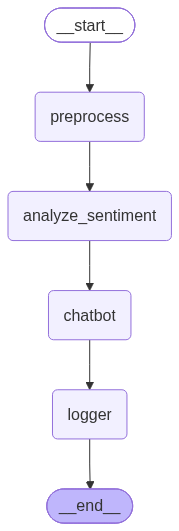

In [11]:
builder.compile()

In [12]:
graph = builder.compile()

In [15]:
input_message = 'This is Ravi Teja working on Langgraph and it is very interesting and good'
final_state = graph.invoke({"messages":('user', input_message)})

print('Final state:', final_state)
print('chatbots responese:', final_state['messages'][-1].content)
print('Detected sentiment:', final_state['sentiment'])

input_message_2 = 'This is neural message'
final_state_2 = graph.invoke({"messages":('user', input_message_2)})

print('Final state 2:', final_state_2)
print('chatbots responese 2:', final_state_2['messages'][-1].content)
print('Detected sentiment 2:', final_state_2['sentiment'])

LOG: It's great to hear that you're finding Langgraph interesting and enjoyable to work with, Ravi Teja. Langgraph is a cutting-edge tool that has the potential to revolutionize the way we interact with language models. What specific aspects of Langgraph are you finding most interesting or useful? Are you exploring its capabilities for text generation, language translation, or something else? I'm here to help and learn more about your experience with Langgraph!, Sentiment: positive
Final state: {'messages': [HumanMessage(content='This is Ravi Teja working on Langgraph and it is very interesting and good', additional_kwargs={}, response_metadata={}, id='6769bf0a-c39e-4af7-97ea-74999d9f4fed'), AIMessage(content="It's great to hear that you're finding Langgraph interesting and enjoyable to work with, Ravi Teja. Langgraph is a cutting-edge tool that has the potential to revolutionize the way we interact with language models. What specific aspects of Langgraph are you finding most interesti